In [1]:
# main.py
import numpy as np
import gym
#from DDPG_trial import DDPG
from collections import deque
import pdb
import torch
from env import env
from LSTM import LSTMModel  
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt

import pdb 
M, N, J = 10, 4, 3
# Replay Buffer for Experience Replay
class ReplayBuffer:
    def __init__(self, max_size=int(1e6)):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, next_state, action, reward):
        self.buffer.append((state, next_state, action, reward))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, next_state, action, reward = map(np.stack, zip(*batch))
        return (
            torch.FloatTensor(state),
            torch.FloatTensor(next_state),
            torch.FloatTensor(action),
            torch.FloatTensor(reward).unsqueeze(1),
            #torch.FloatTensor(done).unsqueeze(1),
        )

    def size(self):
        return len(self.buffer)

###########generate random discrete matrix for actions(should ideally come from the discretization procedure)


def generate_matrix(N, J):
    # Initialize an NxJ matrix filled with zeros
    matrix = np.zeros((N, J), dtype=int)
    
    # Ensure each column has at least one 1
    for j in range(J):
        # Randomly select a row to place the 1 in column j
        while True:
            row_index = np.random.randint(N)
            # Place the 1 only if that row currently contains no 1
            if np.sum(matrix[row_index]) == 0:
                matrix[row_index, j] = 1
                break
    
    # Fill remaining rows with either a single 1 or all 0s
    for i in range(N):
        if np.sum(matrix[i]) == 0:  # If the row is all zeros
            if np.random.rand() > 0.5:  # 50% chance to add a 1
                col_index = np.random.randint(J)
                matrix[i, col_index] = 1
    
    return matrix


In [2]:
#model = torch.load('LSTM.pth')
# Initialize the model architecture
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model parameters
input_dim = N
hidden_dim = 128
output_dim = N
num_layers = 1

# Initialize the model, loss function and optimizer
model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)
#model = LSTMModel()  # Initialize your model with the required parameters

# Load the saved state dictionary
model.load_state_dict(torch.load('LSTM_state_dict_50k.pth'))


C:\Users\sriniva3\AppData\Local\Temp\ipykernel_11124\3206326457.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('LSTM_state_dict_50k.pt

<All keys matched successfully>

In [3]:
Ts = 50000
environ = env(Ts = Ts, N = N, M = M, J= J )
alltime_fast_fading_gains, ff_gains = environ.fast_fading_channel_coefficients()
TxRxds = environ.compute_TxRX()
alltime_PathGains = environ.large_scale_fading_channel_coefficients(TxRxds)

100%|██████████████████████████████████████████████████████████████████████████| 49999/49999 [00:19<00:00, 2613.20it/s]


In [4]:
TimeVaris = np.arange(0,5,5/Ts)
len(TimeVaris)

50000

In [19]:
pwd

'C:\\Users\\sriniva3\\OneDrive - Aalto University\\Simulations\\from git base codes\\latest git codesfeb2025\\base-codes\\X_subnets_MADRL'

In [5]:
def get_lstm_pred_SINR(ts_start, ts_end):
    history = 10
    SINR_nxt_lstm = np.zeros((J,N))
    for j in range(J):
        inp = []
        for ts in np.arange(ts_start, ts_end):
            SINR =  environ.get_next_state(alltime_PathGains, alltime_fast_fading_gains, ts = ts)[0]
            inp.append(SINR[:,j])
        inp = np.array(inp).reshape(1,history,N)
        SINR_nxt_lstm[j,:] = model(torch.Tensor(inp)).detach().numpy()[0]
    SINR_nxt_lstm = np.transpose(SINR_nxt_lstm)
    return SINR_nxt_lstm


In [6]:
'''
b_prev_actions =  generate_matrix(N, J)
state_lstm = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)
state = np.stack((np.multiply(state_lstm, b_prev_actions),b_prev_actions), axis = 0)
b_prsnt_actions =  generate_matrix(N, J)
nxt_state_lstm = get_lstm_pred_SINR(ts_start = 1, ts_end = 11)
next_state = np.stack((np.multiply(nxt_state_lstm, b_prsnt_actions),b_prsnt_actions), axis = 0)
'''

'\nb_prev_actions =  generate_matrix(N, J)\nstate_lstm = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)\nstate = np.stack((np.multiply(state_lstm, b_prev_actions),b_prev_actions), axis = 0)\nb_prsnt_actions =  generate_matrix(N, J)\nnxt_state_lstm = get_lstm_pred_SINR(ts_start = 1, ts_end = 11)\nnext_state = np.stack((np.multiply(nxt_state_lstm, b_prsnt_actions),b_prsnt_actions), axis = 0)\n'

In [7]:
# Actor Network
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64, action_dim)
        self.max_action = max_action

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x * self.max_action

# Critic Network
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_value = self.fc3(x)
        #pdb.set_trace()
        return q_value

In [8]:
# DDPG Agent
class DDPG:
    def __init__(self, state_dim, action_dim, max_action):
        self.actor = Actor(state_dim, action_dim, max_action).to(torch.device("cpu"))
        self.actor_target = Actor(state_dim, action_dim, max_action).to(torch.device("cpu"))
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=1e-3)

        self.critic = Critic(state_dim, action_dim).to(torch.device("cpu"))
        self.critic_target = Critic(state_dim, action_dim).to(torch.device("cpu"))
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

        self.max_action = max_action
        self.discount = 0.99
        self.tau = 0.005

    def select_action(self, state):
        state = torch.FloatTensor(state.reshape(1, -1)).to(torch.device("cpu"))
        action = self.actor(state).cpu().data.numpy().flatten()
        return action

    def train(self, replay_buffer, t, batch_size=64):
        # Sample a batch of transitions from the replay buffer
        state, next_state, action, reward = replay_buffer.sample(batch_size)
        next_state = next_state.view(batch_size,-1)
        state = state.view(batch_size,-1)
        action = action.view(batch_size,-1)
        # Compute the target Q value
        #pdb.set_trace()
        next_action = self.actor_target(next_state)
        target_q = self.critic_target(next_state, next_action)
        #target_q1, target_q2 = self.critic_target(next_state, next_action)
        #target_q = torch.min(target_q1, target_q2)
        if t < 256:
            not_done = 1.0
        else:
            not_done = 0.0
        #pdb.set_trace()
        target_q = reward + not_done * self.discount * target_q.detach()

        # Get current Q estimate
        current_q = self.critic(state, action)
        #current_q1, current_q2 = self.critic(state, action)
        #current_q = torch.min(current_q1, current_q2)
        # Compute critic loss
        critic_loss = F.mse_loss(current_q, target_q)

        # Optimize the critic
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Compute actor loss
        actor_loss = -self.critic(state, self.actor(state)).mean()

        # Optimize the actor
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Update the target networks
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

In [13]:
T = 256
############# get initial states  #############
'''
b_prev_actions =  generate_matrix(N, J)
state_lstm = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)
state = np.stack((np.multiply(state_lstm, b_prev_actions),b_prev_actions), axis = 0)
b_prsnt_actions =  generate_matrix(N, J)
nxt_state_lstm = get_lstm_pred_SINR(ts_start = 1, ts_end = 11)
next_state = np.stack((np.multiply(nxt_state_lstm, b_prsnt_actions),b_prsnt_actions), axis = 0)
'''
############################################################
state_dim = 2*N*J
action_dim = N*J
max_action = 1.0
time_slots = np.arange(0,Ts)

agent = DDPG(state_dim, action_dim, max_action)
agent2 = DDPG(state_dim, action_dim, max_action)

replay_buffer = ReplayBuffer()
replay_buffer2 = ReplayBuffer()

#train_agents(env, agent1, agent2, replay_buffer)
episodes=500
batch_size=128

ts_counter = 0

######## generate interactions dummy ###########
interfers_actions = np.zeros((M-1, J, N)) # should be the actions from other agent. 
for i, m in enumerate(range(M-1)):
    interfers_actions[i,:,:] = np.transpose(generate_matrix(N, J))

In [14]:
epi_rewards = []
epi_rewards2 = []
b_prev_actions =  generate_matrix(N, J)
P_e = []
P_e2 = []
for episode in range(episodes):
        ############# get initial states  #############
        if episode == 0:
            state_lstm = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)
        else:
            state_lstm = get_lstm_pred_SINR(ts_start = ts_counter, ts_end = ts_counter+10)
        #state = np.stack((np.multiply(state_lstm, b_prev_actions),b_prev_actions), axis = 0)
        state = np.stack((state_lstm,b_prev_actions), axis = 0)
        state2 = np.stack((state_lstm,b_prev_actions), axis = 0)
        #b_prsnt_actions =  generate_matrix(N, J)
        #nxt_state_lstm = get_lstm_pred_SINR(ts_start = 1, ts_end = 11)
        #next_state = np.stack((np.multiply(nxt_state_lstm, b_prsnt_actions),b_prsnt_actions), axis = 0)
        ############################################################
        episode_reward = 0
        episode_reward2 = 0
        for t in range(T):
            action = agent.select_action(np.array(state))
            action2 = agent2.select_action(np.array(state2))
            #action =  (action >= 0.5).astype(float)
            #next_state, reward, done, _ = env.step(action)
            nxt_state_lstm = get_lstm_pred_SINR(ts_start = ts_counter+1, ts_end = ts_counter + 11)
            #next_state = np.stack((np.multiply(nxt_state_lstm, action.reshape(N,J)),action.reshape(N,J)), axis = 0)
            next_state = np.stack((nxt_state_lstm,action.reshape(N,J)), axis = 0)
            next_state2 = np.stack((nxt_state_lstm,action.reshape(N,J)), axis = 0)
            
            state = next_state
            state2 = next_state2
            #reward = np.sum(environ.compute_rewards(alltime_PathGains, alltime_fast_fading_gains, ts = time_slots[ts_counter + 10],
                                                    #b = 0, interfers_actions = interfers_actions, b_actions = b_prev_actions)[2])
            _, p_e, reward = environ.compute_rewards(alltime_PathGains, alltime_fast_fading_gains, ts = time_slots[ts_counter + 10],
                                                    b = 0, interfers_actions = interfers_actions, b_actions = b_prev_actions)
            _, p_e2, reward2 = environ.compute_rewards(alltime_PathGains, alltime_fast_fading_gains, ts = time_slots[ts_counter + 10],
                                                    b = 1, interfers_actions = interfers_actions, b_actions = b_prev_actions)
            
            P_e.append(p_e)
            P_e2.append(p_e2)
            
            reward = np.sum(reward)
            reward2 = np.sum(reward2)
            
            #print(t, p_e, reward)
            episode_reward += reward
            episode_reward2 += reward2
            
            replay_buffer.add(state, next_state, action.reshape(N,J), reward)
            replay_buffer2.add(state2, next_state2, action2.reshape(N,J), reward2)

            if replay_buffer.size() > batch_size:
                agent.train(replay_buffer, t, batch_size)
            if replay_buffer2.size() > batch_size:
                agent2.train(replay_buffer2, t, batch_size)
            ts_counter+=1
            if ts_counter == Ts - 10:
                ts_counter = 0
            #print(ts_counter)
        b_prev_actions = action.reshape(N,J)
        b_prev_actions2 = action2.reshape(N,J)
        
        print(f"Episode: {episode + 1}, Reward: {episode_reward/256}")
        print(f"Episode: {episode + 1}, Reward: {episode_reward2/256}")
        
        epi_rewards.append(episode_reward/256)
        epi_rewards2.append(episode_reward2/256)

Episode: 1, Reward: -5.068197029646765
Episode: 1, Reward: -13.296132234652534
Episode: 2, Reward: 15.071766301691882
Episode: 2, Reward: 15.071766301691882


C:\Users\sriniva3\OneDrive - Aalto University\Simulations\from git base codes\latest git codesfeb2025\base-codes\X_subnets_MADRL\env.py:342: RuntimeWarning: divide by zero encountered in divide
  Q_term = (2*n*C_gamma - 2*k + np.log2(n))/(2*n*np.sqrt(V_gamma))


Episode: 3, Reward: 3.119471568366349
Episode: 3, Reward: 3.119471568366349
Episode: 4, Reward: 0.833364895029571
Episode: 4, Reward: 0.833364895029571
Episode: 5, Reward: 3.5789326395048615
Episode: 5, Reward: 3.3398536945596944
Episode: 6, Reward: 3.9720371806098522
Episode: 6, Reward: 3.2519306230018077
Episode: 7, Reward: -0.04302516704337782
Episode: 7, Reward: -0.07268524082294277
Episode: 8, Reward: 3.578600014723132
Episode: 8, Reward: 3.549549694467463
Episode: 9, Reward: 1.4421253101534284
Episode: 9, Reward: 1.1957231499976018
Episode: 10, Reward: 1.4166194635810518
Episode: 10, Reward: 0.873427919035454
Episode: 11, Reward: 5.527087754930503
Episode: 11, Reward: 5.370127270294044
Episode: 12, Reward: 16.14581730241305
Episode: 12, Reward: 16.14581730241305
Episode: 13, Reward: 16.434913364423668
Episode: 13, Reward: 16.421533677348457
Episode: 14, Reward: 12.620745760195097
Episode: 14, Reward: 12.620745760195097
Episode: 15, Reward: 7.595733620414647
Episode: 15, Reward: 7

Episode: 107, Reward: 25.178190753796454
Episode: 107, Reward: 25.178190753796454
Episode: 108, Reward: 25.508074854782816
Episode: 108, Reward: 25.508074854782816
Episode: 109, Reward: 21.264235089886693
Episode: 109, Reward: 21.264235089886693
Episode: 110, Reward: 21.68350065134984
Episode: 110, Reward: 21.68350065134984
Episode: 111, Reward: 18.869270427276597
Episode: 111, Reward: 18.869270427276597
Episode: 112, Reward: 25.036472582783503
Episode: 112, Reward: 25.036472582783503
Episode: 113, Reward: 21.183617409536392
Episode: 113, Reward: 21.183617409536392
Episode: 114, Reward: 19.66702475432096
Episode: 114, Reward: 19.66702475432096
Episode: 115, Reward: 18.150145858614227
Episode: 115, Reward: 18.150145858614227
Episode: 116, Reward: 18.994380338928522
Episode: 116, Reward: 18.990480806570915
Episode: 117, Reward: 25.467497298494578
Episode: 117, Reward: 25.467497298494578
Episode: 118, Reward: 21.61444733050883
Episode: 118, Reward: 21.61444733050883
Episode: 119, Reward: 

Episode: 209, Reward: 10.415659013322573
Episode: 209, Reward: 10.415659013322573
Episode: 210, Reward: 8.43841195454408
Episode: 210, Reward: 8.178958584386258
Episode: 211, Reward: 13.545848490677434
Episode: 211, Reward: 13.545848490677434
Episode: 212, Reward: 12.111800733156937
Episode: 212, Reward: 12.109580063774441
Episode: 213, Reward: 10.346038007889588
Episode: 213, Reward: 10.346038007889588
Episode: 214, Reward: 7.544007479232102
Episode: 214, Reward: 7.544007479232102
Episode: 215, Reward: 10.555728105554001
Episode: 215, Reward: 10.555728105554001
Episode: 216, Reward: 14.319630562471264
Episode: 216, Reward: 14.319630562471264
Episode: 217, Reward: 14.377677726184844
Episode: 217, Reward: 13.34809892573289
Episode: 218, Reward: 12.885124355235842
Episode: 218, Reward: 12.67527054805597
Episode: 219, Reward: 10.59131236469036
Episode: 219, Reward: 10.59131236469036
Episode: 220, Reward: 5.790598187686089
Episode: 220, Reward: 5.521115205477337
Episode: 221, Reward: 6.515

Episode: 311, Reward: 19.993691439616907
Episode: 311, Reward: 19.9897919072593
Episode: 312, Reward: 23.90096789819548
Episode: 312, Reward: 23.90096789819548
Episode: 313, Reward: 22.03376025689998
Episode: 313, Reward: 22.03376025689998
Episode: 314, Reward: 21.218273130603794
Episode: 314, Reward: 21.218273130603794
Episode: 315, Reward: 22.49247600304451
Episode: 315, Reward: 22.49247600304451
Episode: 316, Reward: 21.550826743939478
Episode: 316, Reward: 21.550826743939478
Episode: 317, Reward: 20.201543417290026
Episode: 317, Reward: 20.201543417290026
Episode: 318, Reward: 22.55902904548057
Episode: 318, Reward: 22.55902904548057
Episode: 319, Reward: 16.373905953203675
Episode: 319, Reward: 16.373905953203675
Episode: 320, Reward: 16.287553440410633
Episode: 320, Reward: 16.287553440410633
Episode: 321, Reward: 13.633290954795577
Episode: 321, Reward: 13.633290954795577
Episode: 322, Reward: 22.521891210192553
Episode: 322, Reward: 22.521891210192553
Episode: 323, Reward: 17.2

Episode: 413, Reward: 9.278190986219505
Episode: 413, Reward: 8.216492935242151
Episode: 414, Reward: 13.79960139524881
Episode: 414, Reward: 13.79960139524881
Episode: 415, Reward: 7.629483159871311
Episode: 415, Reward: 7.4995603612468145
Episode: 416, Reward: 1.643862101061718
Episode: 416, Reward: 0.3458253925140165
Episode: 417, Reward: 14.69202328394634
Episode: 417, Reward: 14.688726749910169
Episode: 418, Reward: 16.418364429371987
Episode: 418, Reward: 16.41634723861494
Episode: 419, Reward: 9.877251711615104
Episode: 419, Reward: 9.863538651997567
Episode: 420, Reward: 21.894685232488182
Episode: 420, Reward: 21.894685232488182
Episode: 421, Reward: 18.8845749958346
Episode: 421, Reward: 18.8845749958346
Episode: 422, Reward: 12.638837007369736
Episode: 422, Reward: 12.638837007369736
Episode: 423, Reward: 13.632549911463624
Episode: 423, Reward: 13.616178414617455
Episode: 424, Reward: 16.832892976570804
Episode: 424, Reward: 16.692364081188583
Episode: 425, Reward: 24.09122

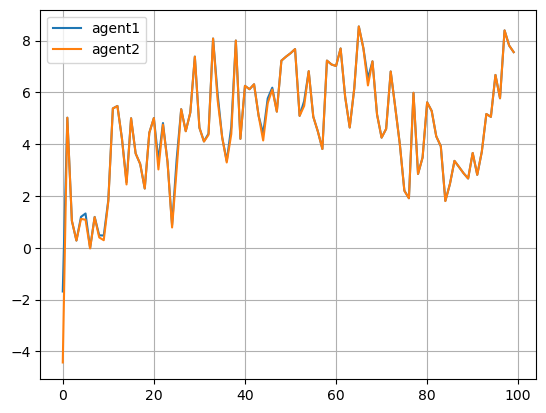

In [17]:
plt.plot(np.array(epi_rewards)[0:100]/J, label = 'agent1')
plt.plot(np.array(epi_rewards2)[0:100]/J, label = 'agent2')
plt.legend()
plt.grid()

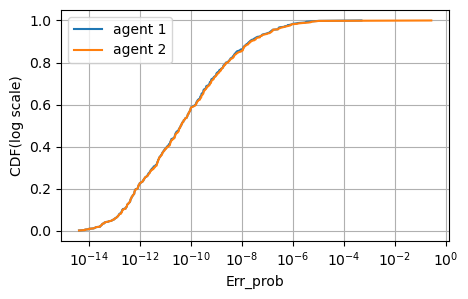

In [16]:
p_o =  1e-5
#rewards = np.array(epi_rewards)/J
err_prob = p_o*(np.power(10,-np.array(epi_rewards)/J))
err_prob2 = p_o*(np.power(10,-np.array(epi_rewards2)/J))

def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf

a, cdf = return_cdf(err_prob)
a2, cdf2 = return_cdf(err_prob2)
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogx(a, cdf, label = r'agent 1')
plt.semilogx(a2, cdf2, label = r'agent 2')
plt.grid()
plt.xlabel('Err_prob')
plt.ylabel('CDF(log scale)')
plt.legend()